In [1]:
from xaikd import models, datasets, utils
from xaikd.utils import metrics
import torch
from torch.utils.data import random_split, DataLoader
from torch import nn
from torch.nn import functional as F
from datetime import datetime
import numpy as np

from tqdm.notebook import tqdm

from numpy import typing as npt

import os

from matplotlib import pyplot as plt
import pandas as pd

In [2]:
# DATASET_NAME = "cifar100-aquatic_mammals"
DATASET_NAME = "cifar100-people"

MODEL_NAME = "cifar100-resnet18-v1"
DATASIZE = 0.1
DEVICE = utils.get_device()

DEVICE

'cuda'

In [3]:
dataset = datasets.construct(DATASET_NAME)

In [4]:
trng = torch.Generator()
trng.manual_seed(1)

ds_train = dataset.create_subset(train_split=True)

ds_train, _ = random_split(
    ds_train,
    [DATASIZE, 1.0-DATASIZE],
    generator=trng
)

ds_val = dataset.create_subset(train_split=False)

dl_train = datasets.build_dataloader(ds_train, shuffle=False)
dl_val = datasets.build_dataloader(ds_val, shuffle=False)

In [5]:
model = models.get_trained_model(MODEL_NAME)
utils.modify_last_layer_for_subclasses(model, dataset.selected_classes)

model.to(DEVICE);

In [6]:
ref_acc, ref_xent = metrics.accuracy(
    model=model,
    dataloader=dl_val,
    num_classes=len(dataset.selected_classes),
    device=DEVICE,
)

# Extract Activation and Grad

In [7]:
class OutputQuantity:
    def __call__(self, logits, target_logits):
        raise NotImplementedError()
    def __str__(self):
        return self.__class__.__name__


def compute_log_odd_winning(logits: torch.Tensor) -> torch.Tensor:

    ns, nc = logits.shape

    values, _ = torch.topk(logits, dim=1, k=nc)

    logit_winning = values[:, 0]
    lse_others = torch.logsumexp(values[:, 1:], dim=1)
    log_odd = logit_winning - lse_others

    return log_odd

        
class LogOddWinningClass(OutputQuantity):
    def __call__(self, logits, targets):
        return torch.sign(logits).detach() * logits
        return compute_log_odd_winning(logits)



class DifferenceTop2WinningClassesEvidence(OutputQuantity):
    def __init__(self, num_classes: int) -> None:
        self.num_classes = num_classes

    def __call__(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        logits = logits.clone()
        # find the label of two winning classes
        _, indices = torch.topk(logits, dim=1, k=2)
        return logits * F.one_hot(indices[:, 0], self.num_classes) - logits.abs() * F.one_hot(
            indices[:, 1], self.num_classes
        )


class LogitWinningClass(OutputQuantity):
    def __call__(self, logits, targets):
        values, _ = torch.topk(logits, dim=1, k=1)

        logit_winning = values[:, 0]
        return logit_winning


OUTPUT_QUANTITY = DifferenceTop2WinningClassesEvidence(num_classes=len(dataset.selected_classes))
# OUTPUT_QUANTITY = LogOddWinningClass()

def extract_activation_context(
    model: nn.Module,
    layer: str,
    data_loader: DataLoader,
    rng: np.random.Generator,
    device="cpu",
    number_of_selected_spatial_locations=20,
    strict_mode=False,
    verbose=False,
):
    arr_act = []
    arr_ctx = []

    output_quantity = OUTPUT_QUANTITY
    try:
        module, hook = utils.interceptor.attach_hook_intercept_layer_output(
            model, layer, should_retain_grad=True, detach_output=False
        )

        for batch in tqdm(data_loader, desc=f"extract act ctx output_quantity={output_quantity.__class__.__name__}) at layer={layer}"):
            x, y = batch
            x = x.to(device)


            logits = model(x)
            (output_quantity(logits, y)).sum().backward()
            act = utils.interceptor.get_output(module)
            output_dimensions = act.shape[1:]

            assert act.grad is not None
            ctx = act.grad

            assert ctx.shape == act.shape
            
            act = act.detach().cpu().numpy()
            ctx = ctx.detach().cpu().numpy()

            selected_act, selected_ctx = utils.subsample_tensors(
                act,
                ctx,
                num_locations=number_of_selected_spatial_locations,
                rng=rng,
            )
            arr_act.append(selected_act)
            arr_ctx.append(selected_ctx)

    finally:
        hook.remove()

    print(f"{layer}: output-dims={output_dimensions}")

    arr_act = np.vstack(arr_act)
    arr_ctx = np.vstack(arr_ctx)

    return arr_act, arr_ctx


def extract_act_grad(model, layer, dl):
    


    return extract_activation_context(
        model=model,
        layer=layer,
        data_loader=dl,
        rng=np.random.default_rng(seed=1),
        device=DEVICE,
    )

extract_act_grad(model, "avgpool", dl_train)

extract act ctx output_quantity=DifferenceTop2WinningClassesEvidence) at layer=avgpool:   0%|          | 0/4 […

avgpool: output-dims=torch.Size([512, 1, 1])


(array([[0.10102677, 0.960209  , 0.3827793 , ..., 0.0601557 , 0.5523869 ,
         0.37362525],
        [0.30660984, 2.3266697 , 0.03504136, ..., 0.08452825, 0.01399533,
         0.04893738],
        [0.01976126, 0.7626184 , 0.00302856, ..., 0.04187122, 0.12033181,
         0.00557438],
        ...,
        [0.04629413, 1.1809896 , 0.42448714, ..., 0.20044588, 0.01310524,
         0.47162923],
        [0.08555653, 1.8575144 , 0.        , ..., 0.        , 0.3009705 ,
         0.09433806],
        [0.05903496, 1.4818411 , 1.5698389 , ..., 0.10980165, 1.6403408 ,
         0.3017176 ]], dtype=float32),
 array([[-0.00624179, -0.00329058,  0.04387233, ..., -0.0268096 ,
          0.00982302,  0.13893944],
        [-0.02274627, -0.05537367,  0.07718536, ...,  0.10169219,
         -0.08202638,  0.1230265 ],
        [ 0.01595507,  0.03867373, -0.15698762, ..., -0.05084414,
         -0.08241361, -0.10128602],
        ...,
        [ 0.02131429, -0.00938439,  0.02508621, ...,  0.0882884 ,
         

# Construing Basis

In [8]:
def _solve_eigvecs(cov, sort_func=lambda x: x):
    eigvals, eigvecs = np.linalg.eigh(cov)

    assert len(eigvals.shape) == 1

    indices = np.argsort(-sort_func(eigvals))
    eigvals = eigvals[indices]
    eigvecs = eigvecs[:, indices]

    return eigvecs, eigvals
    
class BasisInterface:
    def get_Uk(self, k: int) -> npt.NDArray:
        raise NotImplementedError()   

class PCA(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):
        cov = arr_act.T @ arr_act
        self.U, self.eigvals = _solve_eigvecs(cov)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]


class GradPCA(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):
        cov = arr_ctx.T @ arr_ctx
        self.U, self.eigvals = _solve_eigvecs(cov)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]

class PRCASortAbs(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):
        cov = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act
        self.U, _ = _solve_eigvecs(cov, sort_func=np.abs)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]


class PRCA(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):
        cov = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act
        self.U, _ = _solve_eigvecs(cov)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]



class PRCAPosDef(BasisInterface):
    def __init__(self, arr_act, arr_ctx, layer=None, task_id=None):

        pca = PCA(arr_act=arr_act, arr_ctx=arr_ctx)
        gradpca = GradPCA(arr_act=arr_act, arr_ctx=arr_ctx)
        
        arr_act = arr_act / ( np.sum(pca.eigvals) ** 0.5)
        arr_ctx = arr_ctx / ( np.sum(gradpca.eigvals) ** 0.5)


        cov_a = 2*(arr_act.T @ arr_act)
        cov_c = 2*(arr_ctx.T @ arr_ctx)
        cov_ac = arr_act.T @ arr_ctx + arr_ctx.T @ arr_act
        
        cov = cov_ac + cov_a + cov_c
        
        self.U, self.eigvals = _solve_eigvecs(cov)
        
    def get_Uk(self, k: int):
        return self.U[:, :k]

## Full Jacobian

# Estimating Accuracy

In [9]:
def construct_fh(Uk):
    def fh(mod, inp, outp):
        return F.conv2d(
            outp,
            (Uk@Uk.T).unsqueeze(2).unsqueeze(3)
        )
    return fh

def compute_task_acc_at_k(
    model, layer,  
    arr_ks,
    arr_basis_classes=[PCA],
):


    arr_act, arr_ctx = extract_act_grad(
        model, 
        layer, 
        dl=dl_train, 
    )

    
    module = getattr(model, layer)

    rel = (arr_act  * arr_ctx).sum(axis=1)


    arr_dfs = []

    for basis_class in arr_basis_classes:
        basis: BasisInterface = basis_class(
            arr_act=arr_act, 
            arr_ctx=arr_ctx,
            layer=layer,
        )
        basis_name = basis.__class__.__name__
        arr_stat_rows = []

        for k in tqdm(
            arr_ks,
            desc=f"[{basis_name:<20s}] Estimating Performance"
        ):

            Uk = basis.get_Uk(k=k)

            Uk = torch.from_numpy(Uk).to(DEVICE)
            row = dict(
                layer=layer,
                output_quantity=OUTPUT_QUANTITY.__class__.__name__,
                k=k, 
                basis_name=basis_name,
            )
            try:
                hook = module.register_forward_hook(construct_fh(Uk))
                
                for label, dl in [
                    ("val", dl_val)
                ]:
                    row[f"acc_{label}"], row[f"xent_{label}"] = metrics.accuracy(
                        model=model,
                        dataloader=dl,
                        num_classes=len(dataset.selected_classes),
                        device=DEVICE,
                    )
                
            finally:
                hook.remove()
            arr_stat_rows.append(row)
            
        df = pd.DataFrame(arr_stat_rows)


        arr_dfs.append(df)

    df = pd.concat(arr_dfs).sort_values(by=["k", "acc_val"], ascending=[True, False])
    return df


compute_task_acc_at_k(
    model, layer="avgpool", 
    arr_ks=[1, 2, 5],
    arr_basis_classes=[
        PCA,
        GradPCA,
        PRCA,
        PRCASortAbs,
        PRCAPosDef
    ]
)

extract act ctx output_quantity=DifferenceTop2WinningClassesEvidence) at layer=avgpool:   0%|          | 0/4 […

avgpool: output-dims=torch.Size([512, 1, 1])


[PCA                 ] Estimating Performance:   0%|          | 0/3 [00:00<?, ?it/s]

[GradPCA             ] Estimating Performance:   0%|          | 0/3 [00:00<?, ?it/s]

[PRCA                ] Estimating Performance:   0%|          | 0/3 [00:00<?, ?it/s]

[PRCASortAbs         ] Estimating Performance:   0%|          | 0/3 [00:00<?, ?it/s]

[PRCAPosDef          ] Estimating Performance:   0%|          | 0/3 [00:00<?, ?it/s]

,layer,output_quantity,k,basis_name,acc_val,xent_val
0,avgpool,DifferenceTop2WinningClassesEvidence,1,GradPCA,0.296,1.544345
0,avgpool,DifferenceTop2WinningClassesEvidence,1,PRCA,0.280,1.827377
0,avgpool,DifferenceTop2WinningClassesEvidence,1,PRCASortAbs,0.280,1.827377
0,avgpool,DifferenceTop2WinningClassesEvidence,1,PCA,0.200,1.634521
0,avgpool,DifferenceTop2WinningClassesEvidence,1,PRCAPosDef,0.200,2.476144
1,avgpool,DifferenceTop2WinningClassesEvidence,2,PRCA,0.426,1.883996
1,avgpool,DifferenceTop2WinningClassesEvidence,2,PRCASortAbs,0.426,1.883996
1,avgpool,DifferenceTop2WinningClassesEvidence,2,GradPCA,0.400,1.523730
1,avgpool,DifferenceTop2WinningClassesEvidence,2,PCA,0.356,1.492812
1,avgpool,DifferenceTop2WinningClassesEvidence,2,PRCAPosDef,0.290,2.411123


# Estimate Statistics

In [10]:
MAPPING_LAYER_DIMENSIONS = utils.get_dimensions_at_layers(
    model=model,
    dataloader=dl_train,
    layers=["layer1", "layer2", "layer3", "layer4"],
    device=DEVICE
)

In [11]:
MAPPING_LAYER_DIMENSIONS

{'layer1': 64, 'layer2': 128, 'layer3': 256, 'layer4': 512}

In [12]:
def estimate_stats(
    arr_basis_classes=[
        PCA,
        GradPCA,

        PRCA,
        PRCASortAbs,
        PRCAPosDef,
    ]
):
    arr_dfs = []
    arr_layers = ["layer1", "layer2", "layer3", "layer4"]
    for layer in tqdm(arr_layers):
        d = MAPPING_LAYER_DIMENSIONS[layer]
        arr_ks = np.linspace(1, d, 10).astype(int)
        df = compute_task_acc_at_k(
            model, layer=layer, 
            arr_ks=arr_ks,
            arr_basis_classes=arr_basis_classes
        )
        arr_dfs.append(df)
    return pd.concat(arr_dfs)

df_stats = estimate_stats()

  0%|          | 0/4 [00:00<?, ?it/s]

extract act ctx output_quantity=DifferenceTop2WinningClassesEvidence) at layer=layer1:   0%|          | 0/4 [0…

layer1: output-dims=torch.Size([64, 32, 32])


[PCA                 ] Estimating Performance:   0%|          | 0/10 [00:00<?, ?it/s]

[GradPCA             ] Estimating Performance:   0%|          | 0/10 [00:00<?, ?it/s]

...

[PCA                 ] Estimating Performance:   0%|          | 0/10 [00:00<?, ?it/s]

[GradPCA             ] Estimating Performance:   0%|          | 0/10 [00:00<?, ?it/s]

[PRCA                ] Estimating Performance:   0%|          | 0/10 [00:00<?, ?it/s]

[PRCASortAbs         ] Estimating Performance:   0%|          | 0/10 [00:00<?, ?it/s]

[PRCAPosDef          ] Estimating Performance:   0%|          | 0/10 [00:00<?, ?it/s]

In [13]:
df_stats

,layer,output_quantity,k,basis_name,acc_val,xent_val
0,layer1,DifferenceTop2WinningClassesEvidence,1,PCA,0.200,1.749628
0,layer1,DifferenceTop2WinningClassesEvidence,1,GradPCA,0.196,1.843484
0,layer1,DifferenceTop2WinningClassesEvidence,1,PRCAPosDef,0.194,1.694187
0,layer1,DifferenceTop2WinningClassesEvidence,1,PRCA,0.172,1.684413
0,layer1,DifferenceTop2WinningClassesEvidence,1,PRCASortAbs,0.172,1.684413
...,...,...,...,...,...,...
9,layer4,DifferenceTop2WinningClassesEvidence,512,PCA,0.620,1.294862
9,layer4,DifferenceTop2WinningClassesEvidence,512,GradPCA,0.620,1.294862
9,layer4,DifferenceTop2WinningClassesEvidence,512,PRCA,0.620,1.294862
9,layer4,DifferenceTop2WinningClassesEvidence,512,PRCASortAbs,0.620,1.294862


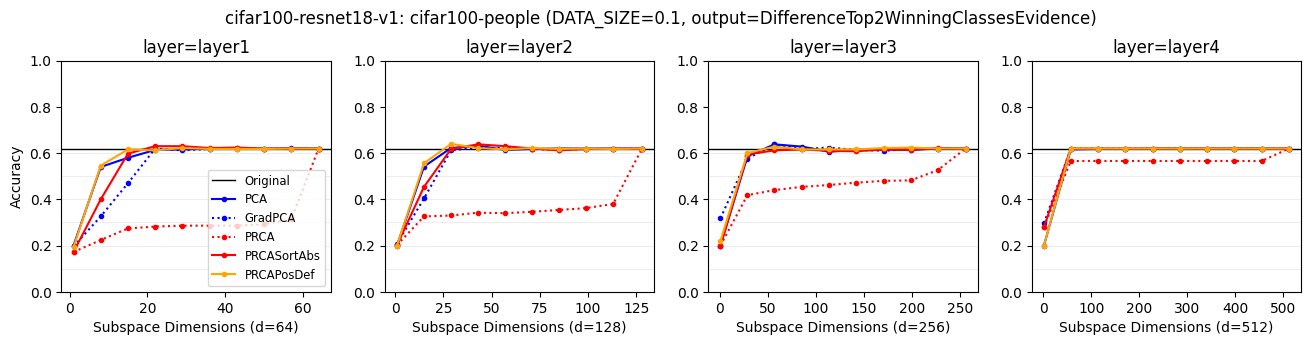

In [14]:
def viz(
    df, 
    arr_basis_classes, 
    dict_ls_color_mapping
):

    def ls_color_mapping(basis_class):
        return dict_ls_color_mapping.get(basis_class, (None, None))

    arr_layers = df.layer.unique()
    ncols = len(arr_layers)
    
    plt.figure(figsize=(4*ncols, 3))
    plt.suptitle(
        f"{MODEL_NAME}: {DATASET_NAME} (DATA_SIZE={DATASIZE}, output={OUTPUT_QUANTITY})", 
        y=1.05
    )

    for lix, layer in enumerate(arr_layers):
        plt.subplot(1, ncols, lix+1)
        plt.title(f"layer={layer}")
        plt.ylim([0, 1])
        d = MAPPING_LAYER_DIMENSIONS[layer]
        
        for bix, basis_class in enumerate(arr_basis_classes):
            basis_name = basis_class.__name__
            _df = df[
                (df.basis_name == basis_name) \
                    & (df.layer==layer)
            ]
            assert _df.shape[0] > 0
            if bix == 0:
                # ref_acc                
                plt.axhline(ref_acc, label="Original", color="k", lw=1, ls="-")
                for v in np.arange(10) * 0.1:
                    if v > ref_acc:
                        break
                        
                    plt.axhline(v, lw=0.5, ls="-", alpha=0.1, color="k")
            ls, color = ls_color_mapping(basis_class)
            plt.plot(
                _df.k,
                _df.acc_val,
                marker=".",
                label=f"{basis_name}",
                ls=ls,
                color=color
            )

        if lix == 0:
            plt.ylabel("Accuracy")
            plt.legend(fontsize="small")
        plt.xlabel(f"Subspace Dimensions (d={d})")
        
viz(
    df_stats,
    arr_basis_classes = [
        PCA,
        GradPCA,
        PRCA,
        PRCASortAbs,
        PRCAPosDef,
    ],
     dict_ls_color_mapping={
         PCA:         ("-", "blue"),
         GradPCA:      (":", "blue"),
         PRCA:         (":", "red"),
         PRCASortAbs:  ("-", "red"),
         PRCAPosDef:    ("-", "orange"),
    }
)

In [15]:
print(f"Finished at {datetime.now()}")

Finished at 2025-02-06 17:03:29.638671
